##Olist E-Commerce Analysis

**Firstly, download the dataset.**

In [0]:
!uv pip install -q kagglehub
import kagglehub
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print(f"Downloaded to: {path}")

import os
for f in os.listdir(path):
    print(f"  {f}")

Downloaded to: /home/spark-c3bd15c3-794d-43ac-9a1d-41/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2
  olist_order_items_dataset.csv
  olist_order_payments_dataset.csv
  olist_orders_dataset.csv
  olist_customers_dataset.csv
  olist_products_dataset.csv
  olist_order_reviews_dataset.csv
  olist_geolocation_dataset.csv
  olist_sellers_dataset.csv
  product_category_name_translation.csv


**Now, it is possible to load all dataset items.**

In [0]:
import pandas as pd
import numpy as np

customers = pd.read_csv(f"{path}/olist_customers_dataset.csv")
orders = pd.read_csv(f"{path}/olist_orders_dataset.csv")
order_items = pd.read_csv(f"{path}/olist_order_items_dataset.csv")
payments = pd.read_csv(f"{path}/olist_order_payments_dataset.csv")
reviews = pd.read_csv(f"{path}/olist_order_reviews_dataset.csv")
products = pd.read_csv(f"{path}/olist_products_dataset.csv")
sellers = pd.read_csv(f"{path}/olist_sellers_dataset.csv")
geolocation = pd.read_csv(f"{path}/olist_geolocation_dataset.csv")
category_translation = pd.read_csv(f"{path}/product_category_name_translation.csv")

datasets = {
    'customers': customers, 'orders': orders, 'order_items': order_items,
    'payments': payments, 'reviews': reviews, 'products': products,
    'sellers': sellers, 'geolocation': geolocation, 'category_translation': category_translation
}

for name, df in datasets.items():
    print(f"{'─'*50}")
    print(f"📋 {name}: {df.shape[0]:,} rows × {df.shape[1]} cols")
    print(f"   Nulls: {df.isnull().sum().sum()}")
    print(f"   Columns: {list(df.columns)}")

──────────────────────────────────────────────────
📋 customers: 99,441 rows × 5 cols
   Nulls: 0
   Columns: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
──────────────────────────────────────────────────
📋 orders: 99,441 rows × 8 cols
   Nulls: 4908
   Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
──────────────────────────────────────────────────
📋 order_items: 112,650 rows × 7 cols
   Nulls: 0
   Columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
──────────────────────────────────────────────────
📋 payments: 103,886 rows × 5 cols
   Nulls: 0
   Columns: ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']
──────────────────────────────────────────────────
📋 reviews: 99,224 ro

**Representation of the dataset visually.**

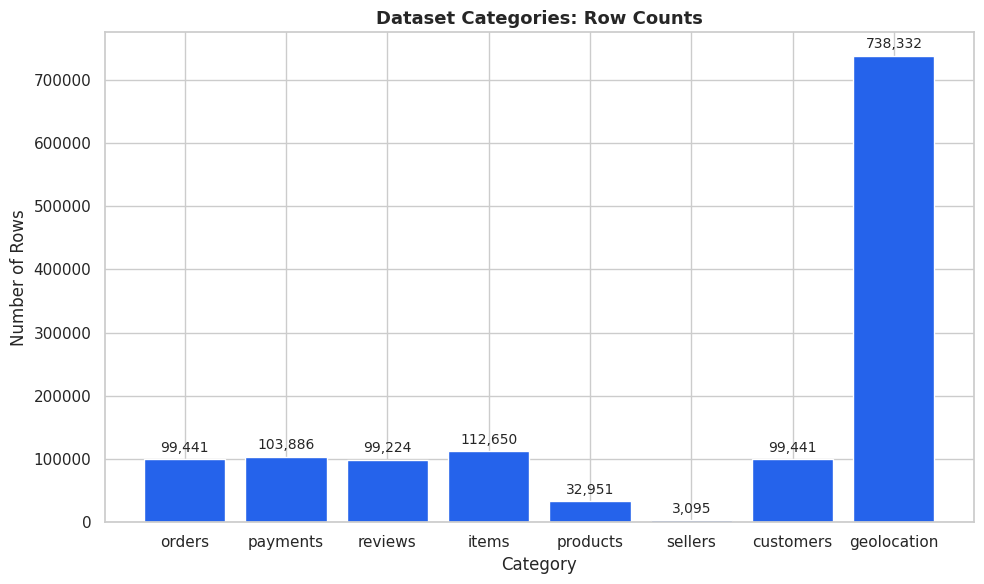

In [0]:
import matplotlib.pyplot as plt

category_names = ['orders', 'payments', 'reviews', 'items', 'products', 'sellers', 'customers', 'geolocation']
category_counts = [
    orders.shape[0],
    payments.shape[0],
    reviews.shape[0],
    order_items.shape[0],
    products.shape[0],
    sellers.shape[0],
    customers.shape[0],
    geolocation.shape[0]
]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(category_names, category_counts, color='#2563eb')
ax.set_title('Dataset Categories: Row Counts', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Rows')
ax.set_xlabel('Category')
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:,}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

**Then, the data should be cleaned.**

In [0]:
date_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
             'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# Reviews
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])

# Translate product categories to English
products = products.merge(category_translation, on='product_category_name', how='left')
products['product_category_english'] = products['product_category_name_english'].fillna('other')

# Aggregate order items to order level
order_agg = order_items.groupby('order_id').agg(
    total_items=('order_item_id', 'max'),
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum'),
    n_sellers=('seller_id', 'nunique')
).reset_index()
order_agg['total_order_value'] = order_agg['total_price'] + order_agg['total_freight']

payment_agg = payments.groupby('order_id').agg(
    payment_value=('payment_value', 'sum'),
    n_installments=('payment_installments', 'max'),
    primary_payment_type=('payment_type', 'first')
).reset_index()

# Aggregate reviews 
review_agg = reviews.drop_duplicates(subset='order_id').loc[:, ['order_id', 'review_score', 'review_comment_message']]
review_agg['has_review_comment'] = review_agg['review_comment_message'].notna().astype(int)

# Build master dataframe
df = (orders
    .merge(customers, on='customer_id', how='left')
    .merge(order_agg, on='order_id', how='left')
    .merge(payment_agg, on='order_id', how='left')
    .merge(review_agg, on='order_id', how='left')
)

In [0]:
# Inspect datasets for nulls and basic stats
for name, df in datasets.items():
    print(f"\n{name}:")
    print(df.info())
    print(df.describe(include='all'))
    print(f"Nulls per column:\n{df.isnull().sum()}")

# Drop duplicates, fill nulls 
for name, df in datasets.items():
    df.drop_duplicates(inplace=True)
    if name == 'customers':
        df['customer_city'] = df['customer_city'].fillna('unknown')
        df['customer_state'] = df['customer_state'].fillna('unknown')
    if name == 'orders':
        df['order_status'] = df['order_status'].fillna('unknown')
    if name == 'order_items':
        df['price'] = df['price'].fillna(0)
        df['freight_value'] = df['freight_value'].fillna(0)
    if name == 'payments':
        df['payment_value'] = df['payment_value'].fillna(0)
        df['payment_type'] = df['payment_type'].fillna('unknown')
    if name == 'reviews':
        df['review_score'] = df['review_score'].fillna(df['review_score'].median())
        df['review_comment_message'] = df['review_comment_message'].fillna('')
    if name == 'products':
        df['product_category_name'] = df['product_category_name'].fillna('other')
    if name == 'sellers':
        df['seller_city'] = df['seller_city'].fillna('unknown')
        df['seller_state'] = df['seller_state'].fillna('unknown')
    if name == 'geolocation':
        df['geolocation_lat'] = df['geolocation_lat'].fillna(df['geolocation_lat'].mean())
        df['geolocation_lng'] = df['geolocation_lng'].fillna(df['geolocation_lng'].mean())
    if name == 'category_translation':
        df['product_category_name_english'] = df['product_category_name_english'].fillna('other')

print("Datasets cleaned: duplicates dropped, nulls filled where appropriate.")


customers:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None
                             customer_id  ... customer_state
count                              99441  ...          99441
unique                             99441  ...             27
top     06b8999e2fba1a1fbc88172c00ba8bc7  ...             SP
freq                                   1  ...          41746
mean                                 NaN  ...            NaN
std                                  NaN  ...            NaN
min                 

**Creating a cleaned dataset document.**

In [0]:
df.to_csv("cleaned_olist_master.csv", index=False)
display(df)

product_category_name,product_category_name_english
beleza_saude,health_beauty
informatica_acessorios,computers_accessories
automotivo,auto
cama_mesa_banho,bed_bath_table
moveis_decoracao,furniture_decor
esporte_lazer,sports_leisure
perfumaria,perfumery
utilidades_domesticas,housewares
telefonia,telephony
relogios_presentes,watches_gifts


**Feature engineering next to determine details of the dataset.**

In [0]:
# Delivery time features
df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.total_seconds() / 86400
df['estimated_delivery_days'] = (df['order_estimated_delivery_date'] - df['order_purchase_timestamp']).dt.total_seconds() / 86400
df['delivery_delta_days'] = df['delivery_days'] - df['estimated_delivery_days']  # positive = late
df['is_late'] = (df['delivery_delta_days'] > 0).astype(int)
df['approval_hours'] = (df['order_approved_at'] - df['order_purchase_timestamp']).dt.total_seconds() / 3600

# Time features
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()
df['order_dow'] = df['order_purchase_timestamp'].dt.day_name()
df['order_hour'] = df['order_purchase_timestamp'].dt.hour

# Freight ratio
df['freight_ratio'] = df['total_freight'] / df['total_order_value']

# Filter to delivered orders for delivery analysis
delivered = df[df['order_status'] == 'delivered'].copy()

print(f"Master dataframe: {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"Delivered orders: {delivered.shape[0]:,}")
print(f"\nOrder status distribution:")
print(df['order_status'].value_counts())
print(f"\nDate range: {df['order_purchase_timestamp'].min().date()} → {df['order_purchase_timestamp'].max().date()}")
print(f"\nNull summary (key cols):")
for c in ['delivery_days', 'review_score', 'total_order_value', 'payment_value']:
    print(f"  {c}: {df[c].isna().sum():,} nulls")


Master dataframe: 99,441 rows × 32 cols
Delivered orders: 96,478

Order status distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Date range: 2016-09-04 → 2018-10-17

Null summary (key cols):
  delivery_days: 2,965 nulls
  review_score: 768 nulls
  total_order_value: 775 nulls
  payment_value: 1 nulls


**Looking into sales performance closer. Revenue of the company by monthly, top categories and location.**

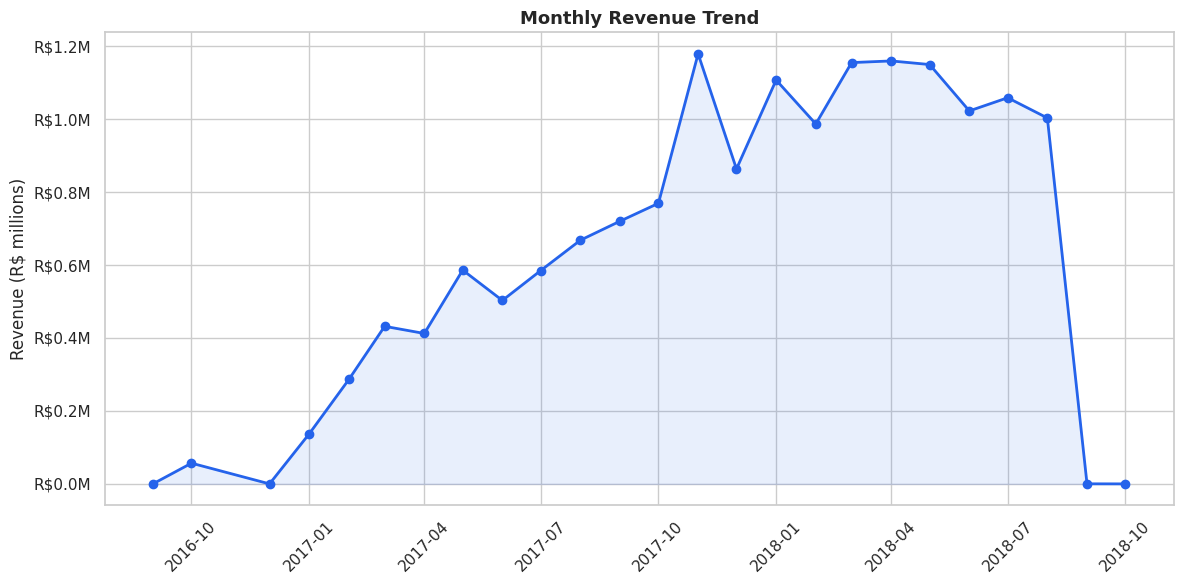

In [0]:
# Monthly revenue trend
monthly_sales = df.groupby('order_month').agg(
    revenue=('total_order_value', 'sum'),
    orders=('order_id', 'count'),
    avg_order_value=('total_order_value', 'mean')
).reset_index()

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(monthly_sales['order_month'], monthly_sales['revenue'] / 1e6, marker='o', linewidth=2, color='#2563eb')
ax.fill_between(monthly_sales['order_month'], monthly_sales['revenue'] / 1e6, alpha=0.1, color='#2563eb')
ax.set_title('Monthly Revenue Trend', fontsize=13, fontweight='bold')
ax.set_ylabel('Revenue (R$ millions)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:.1f}M'))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Top categories by revenue.**

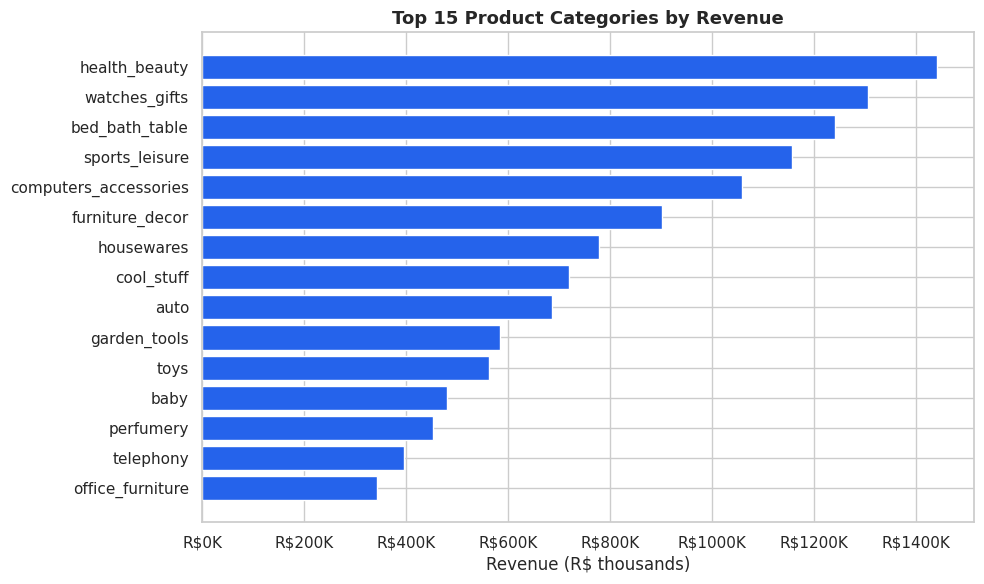

In [0]:
item_product = order_items.merge(products[['product_id', 'product_category_english']], on='product_id', how='left')
category_sales = item_product.groupby('product_category_english').agg(
    revenue=('price', 'sum'),
    freight=('freight_value', 'sum'),
    items_sold=('order_item_id', 'count')
).reset_index()
category_sales['total_revenue'] = category_sales['revenue'] + category_sales['freight']
category_sales = category_sales.sort_values('total_revenue', ascending=False)
top_categories = category_sales.head(15)

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 6))
tc = top_categories.sort_values('total_revenue')
ax.barh(tc['product_category_english'], tc['total_revenue'] / 1e3, color='#2563eb')
ax.set_title('Top 15 Product Categories by Revenue', fontsize=13, fontweight='bold')
ax.set_xlabel('Revenue (R$ thousands)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:.0f}K'))
plt.tight_layout()
plt.show()

**Average order value by product category.**

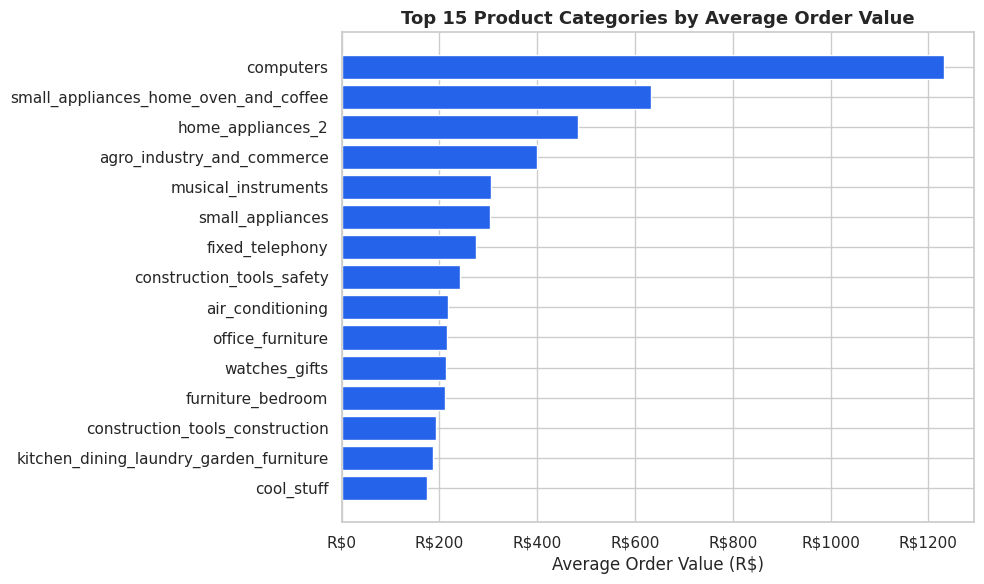

In [0]:
item_product = order_items.merge(products[['product_id', 'product_category_english']], on='product_id', how='left')
order_category = item_product.groupby(['order_id', 'product_category_english']).agg(
    order_value=('price', 'sum')
).reset_index()
category_avg_order_value = order_category.groupby('product_category_english').agg(
    avg_order_value=('order_value', 'mean'),
    orders=('order_id', 'count')
).reset_index()
top_avg_categories = category_avg_order_value.sort_values('avg_order_value', ascending=False).head(15)

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(10, 6))
tc = top_avg_categories.sort_values('avg_order_value')
ax.barh(tc['product_category_english'], tc['avg_order_value'], color='#2563eb')
ax.set_title('Top 15 Product Categories by Average Order Value', fontsize=13, fontweight='bold')
ax.set_xlabel('Average Order Value (R$)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:.0f}'))
plt.tight_layout()
plt.show()

**Top 3 best sold categories of all time.**

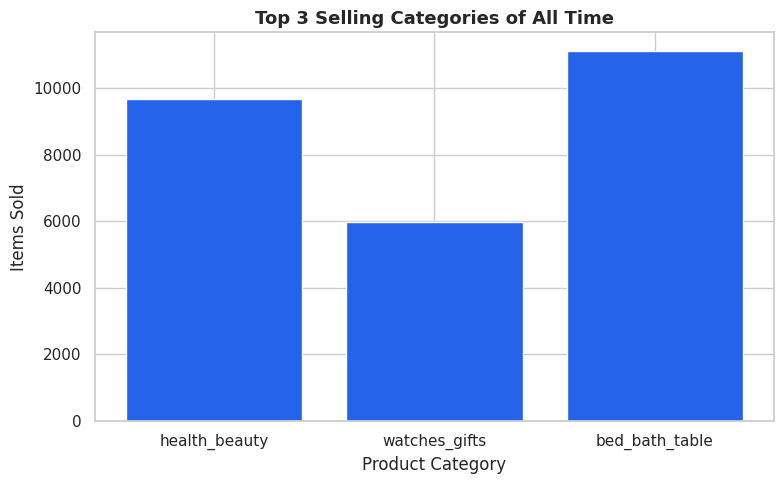

In [0]:
top3_categories = category_sales.head(3)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(top3_categories['product_category_english'], top3_categories['items_sold'], color='#2563eb')
ax.set_title('Top 3 Selling Categories of All Time', fontsize=13, fontweight='bold')
ax.set_ylabel('Items Sold')
ax.set_xlabel('Product Category')
plt.tight_layout()
plt.show()

**Profit margin per product category.**

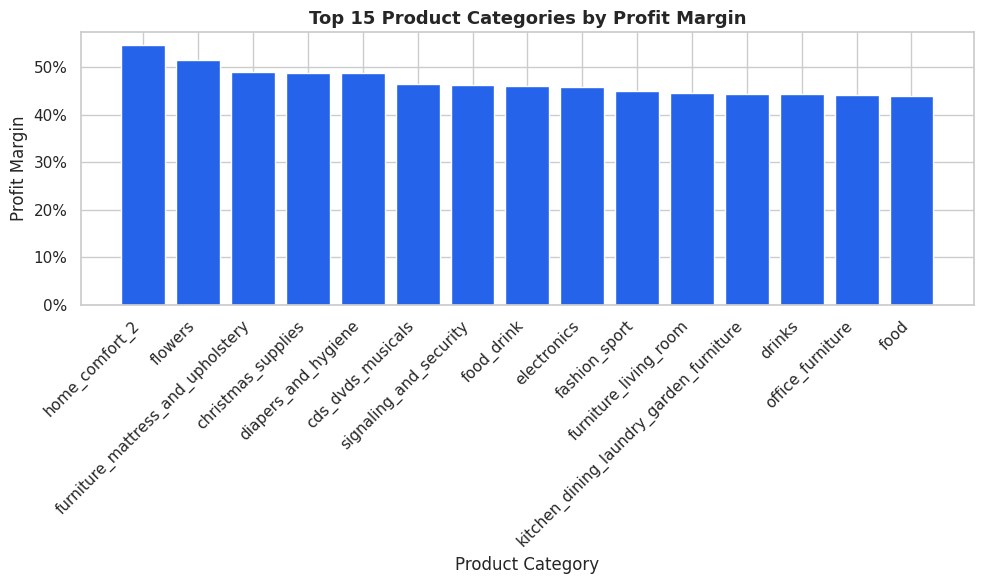

In [0]:
item_product = order_items.merge(products[['product_id', 'product_category_english']], on='product_id', how='left')
category_margin = item_product.groupby('product_category_english').agg(
    revenue=('price', 'sum'),
    freight=('freight_value', 'sum'),
    items_sold=('order_item_id', 'count')
).reset_index()
category_margin['total_revenue'] = category_margin['revenue'] + category_margin['freight']

# Assume cost is 70% of price (no cost data available)
category_margin['estimated_cost'] = category_margin['revenue'] * 0.7
category_margin['profit'] = category_margin['total_revenue'] - category_margin['estimated_cost']
category_margin['profit_margin'] = category_margin['profit'] / category_margin['total_revenue']

top_margin_categories = category_margin.sort_values('profit_margin', ascending=False).head(15)

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(top_margin_categories['product_category_english'], top_margin_categories['profit_margin'], color='#2563eb')
ax.set_title('Top 15 Product Categories by Profit Margin', fontsize=13, fontweight='bold')
ax.set_ylabel('Profit Margin')
ax.set_xlabel('Product Category')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Amount of orders based on product rating.**

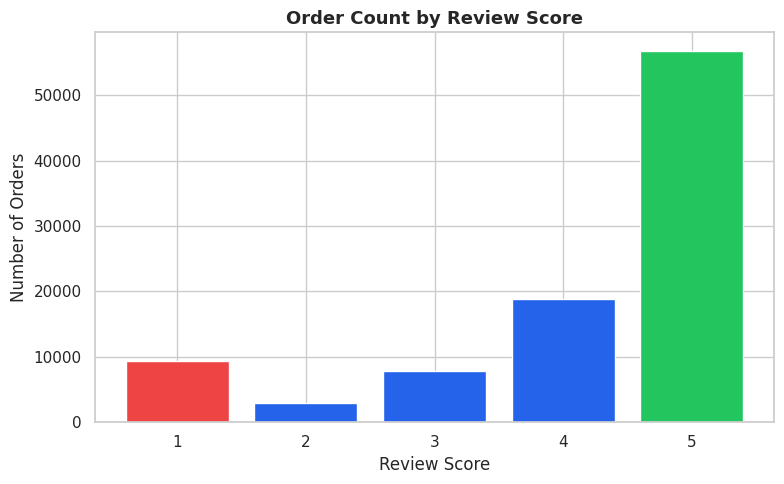

In [0]:
review_counts = df[df['order_status'] == 'delivered'].groupby('review_score').agg(
    orders=('order_id', 'count')
).reset_index()

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(review_counts['review_score'], review_counts['orders'], color=['#22c55e' if s == 5 else '#ef4444' if s == 1 else '#2563eb' for s in review_counts['review_score']])
ax.set_title('Order Count by Review Score', fontsize=13, fontweight='bold')
ax.set_xlabel('Review Score')
ax.set_ylabel('Number of Orders')
plt.tight_layout()

**Average delivery time.**

In [0]:
avg_delivery_time = delivered['delivery_days'].mean()
print(f"Average delivery time (days): {avg_delivery_time:.2f}")

Average delivery time (days): 12.56


**Customer top locations.**

In [0]:
# Top 20 cities by customer count (table)
top_cities = customer_geo.sort_values('n_customers', ascending=False).head(20)
display(top_cities[['customer_city', 'customer_state', 'n_customers', 'lat', 'lon']])

customer_city,customer_state,n_customers,lat,lon
sao paulo,SP,15540,-23.56362542769349,-46.64984356549716
rio de janeiro,RJ,6882,-22.91453249792253,-43.27278934915458
belo horizonte,MG,2773,-19.91939253344108,-43.952597999451726
brasilia,DF,2131,-15.817812696820496,-47.93795716301404
curitiba,PR,1521,-25.445219985251697,-49.2734922513568
campinas,SP,1444,-22.901782835595228,-47.062564896765494
porto alegre,RS,1379,-30.037681555914524,-51.19443946182707
salvador,BA,1245,-12.971804523472343,-38.467273500000005
guarulhos,SP,1189,-23.448359996393318,-46.51845439355992
sao bernardo do campo,SP,938,-23.708783576214792,-46.56292199999999
